# Analisis Sentimen Ulasan Aplikasi Google Play Store
**Proyek Submission – NLP & Deep Learning**

| Atribut | Detail |
|---|---|
| **Dataset Mentah** | >10.000 ulasan dari berbagai aplikasi populer Indonesia |
| **Labeling** | Pendekatan Berbasis Leksikon (Kata Kunci Sentimen) |
| **Balancing** | 3 Kelas Seimbang tepat 5.000 sampel (1.666 Positif, 1.667 Netral, 1.667 Negatif) |
| **Skema 1** | Conv1D + Embedding (Deep Learning, split 80/20) |
| **Skema 2** | Bi-LSTM + Word2Vec (Deep Learning, split 80/20) |
| **Skema 3** | SVM + TF-IDF (Machine Learning, split 80/20) |


In [ ]:
!pip install Sastrawi -q

## 1. Import Library

In [1]:
import os, re, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

import nltk
for p in ['stopwords','punkt','punkt_tab']:
    nltk.download(p, quiet=True)
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, GlobalMaxPooling1D,
                                     Bidirectional, LSTM, Dense, Dropout,
                                     SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
np.random.seed(42); tf.random.set_seed(42)


TensorFlow: 2.21.0


## 2. Load Dataset Mentah

In [2]:
df_raw = pd.read_csv('dataset_ulasan.csv')
print(f"Total data mentah hasil scraping: {len(df_raw)}")
df_raw[['app_name','review','rating']].head(5)


Total data mentah hasil scraping: 10127


,app_name,review,rating
0,Gojek,"lagi urgent, gak bisa trx pake linkaja, plus k...",1
1,Gojek,terbantu sekalo,5
2,Gojek,ramah,5
3,Gojek,"aneh, nyarinya lama kali, udh telat juga untuk...",2
4,Gojek,Mantap,5


## 3. Pelabelan Data (Pendekatan Leksikon)
Karena label berdasarkan rating 1-5 cenderung ambigu pada rating tengah (3 dan 4), 
kita menggunakan pendekatan **Leksikon Kamus Sentimen** untuk memastikan teks ulasan memiliki
sentimen yang jelas (Positif, Netral, atau Negatif).


In [3]:
pos_kw = ['bagus','baik','mantap','keren','suka','cepat','mudah','puas',
          'senang','canggih','hebat','top','beres','stabil','aman',
          'recommended','ramah','sukses','lancar','sempurna','helpful',
          'terima kasih','thanks','luar biasa','terbaik','andalan','juara']
neg_kw = ['buruk','jelek','lambat','error','crash','bug','gagal','susah','payah',
          'kecewa','mengecewakan','mati','force close','loading',
          'lemot','boros','penipuan','bohong','sampah','parah','terburuk',
          'bermasalah','gangguan','kurang']

def lex_label(row):
    t = str(row['review']).lower()
    p = sum(1 for w in pos_kw if w in t)
    n = sum(1 for w in neg_kw if w in t)
    if p > n: return 'Positif'
    elif n > p: return 'Negatif'
    else: return 'Netral'

df_raw['label'] = df_raw.apply(lex_label, axis=1)
print("Distribusi label (keseluruhan data):")
print(df_raw['label'].value_counts())


Distribusi label (keseluruhan data):
label
Netral     5529
Positif    3189
Negatif    1409
Name: count, dtype: int64


### 3.1 Balancing Dataset (Membuat Data Seimbang 5.000 Sampel)
Sesuai kebutuhan, kita menyeimbangkan dataset menjadi tepat 5.000 sampel.
Kelas yang memiliki sampel kurang akan di-oversample sedikit (dengan replacement).


Kelas: ['Negatif' 'Netral' 'Positif']

Dataset Balanced: 5000 sampel
label
Netral     1667
Negatif    1667
Positif    1666
Name: count, dtype: int64


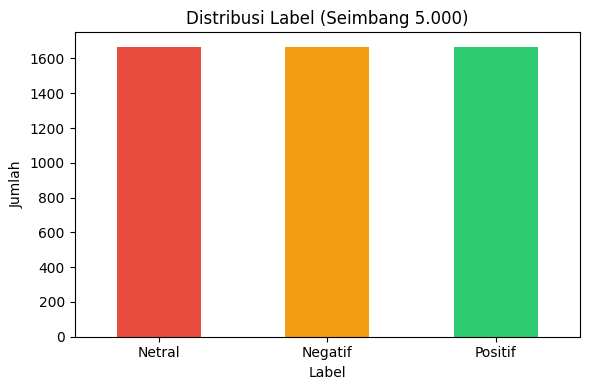

In [4]:
from sklearn.preprocessing import LabelEncoder

df_pos = df_raw[df_raw['label']=='Positif'].sample(1666, random_state=42, replace=(len(df_raw[df_raw['label']=='Positif'])<1666))
df_neu = df_raw[df_raw['label']=='Netral'].sample(1667, random_state=42, replace=(len(df_raw[df_raw['label']=='Netral'])<1667))
df_neg = df_raw[df_raw['label']=='Negatif'].sample(1667, random_state=42, replace=(len(df_raw[df_raw['label']=='Negatif'])<1667))

df = pd.concat([df_pos, df_neu, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print("Kelas:", le.classes_)
print(f"\nDataset Balanced: {len(df)} sampel")
print(df['label'].value_counts())

fig, ax = plt.subplots(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'])
ax.set_title('Distribusi Label (Seimbang 5.000)'); ax.set_xlabel('Label')
ax.set_ylabel('Jumlah'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig('distribusi_label.png', dpi=120); plt.show()


## 4. Preprocessing Teks

In [5]:
factory    = StemmerFactory()
stemmer    = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

slang_dict = {
    'gak':'tidak','ga':'tidak','ngga':'tidak','enggak':'tidak',
    'bgt':'banget','bngt':'banget','bget':'banget',
    'yg':'yang','dgn':'dengan','utk':'untuk','krn':'karena',
    'klo':'kalau','kl':'kalau','tp':'tapi','tpi':'tapi',
    'sy':'saya','gw':'saya','gue':'saya',
    'lg':'lagi','sdh':'sudah','udah':'sudah','udh':'sudah',
    'blm':'belum','jd':'jadi','dpt':'dapat',
    'mantap':'bagus','mantul':'bagus','susah':'sulit',
    'jelek':'buruk','app':'aplikasi','apk':'aplikasi',
}

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\\S+|www\\S+', '', text)
    text = re.sub(r'[^a-z\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [slang_dict.get(t, t) for t in tokens]
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

print("Memulai preprocessing ...")
from tqdm import tqdm
tqdm.pandas()
df['clean_text'] = df['review'].progress_apply(preprocess)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f"Selesai. Data bersih: {len(df)}")


Memulai preprocessing ...


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 2/5000 [00:00<05:58, 13.96it/s]

  0%|          | 4/5000 [00:00<06:33, 12.69it/s]

  0%|          | 6/5000 [00:01<16:56,  4.91it/s]

...

100%|█████████▉| 4982/5000 [03:41<00:00, 39.59it/s]

100%|█████████▉| 4990/5000 [03:41<00:00, 44.27it/s]

100%|█████████▉| 4996/5000 [03:41<00:00, 31.82it/s]

100%|██████████| 5000/5000 [03:41<00:00, 22.52it/s]

Selesai. Data bersih: 4953


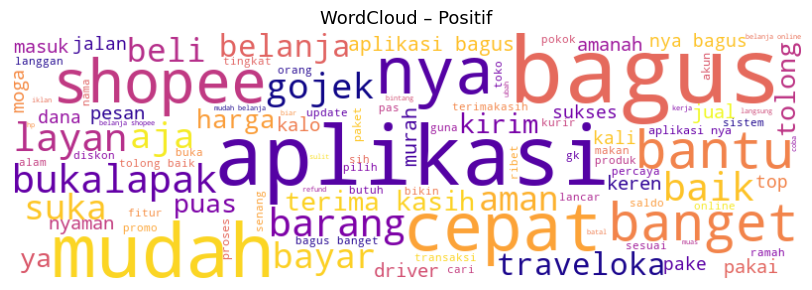

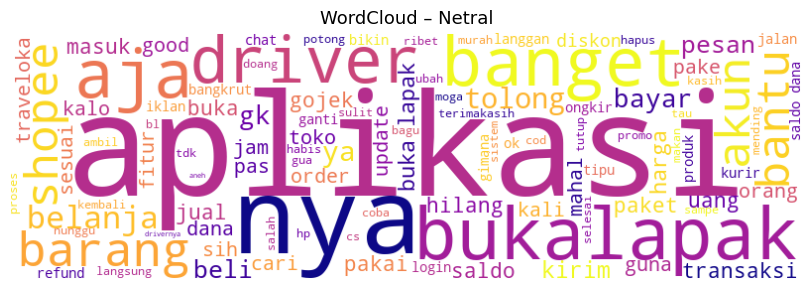

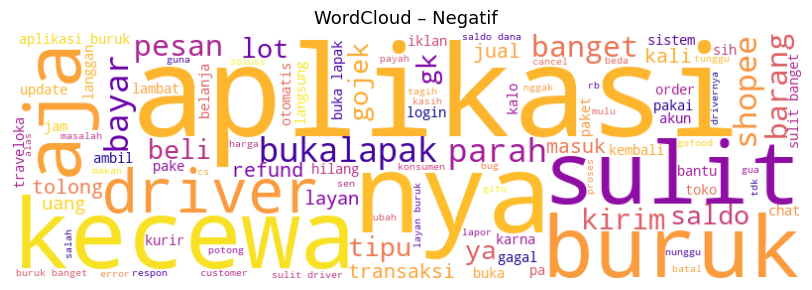

In [6]:
for lbl in ['Positif','Netral','Negatif']:
    txt = ' '.join(df[df['label']==lbl]['clean_text'])
    if not txt.strip(): continue
    wc = WordCloud(width=800, height=250, background_color='white',
                   max_words=100, colormap='plasma').generate(txt)
    plt.figure(figsize=(10,3))
    plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
    plt.title(f'WordCloud – {lbl}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'wordcloud_{lbl.lower()}.png', dpi=100); plt.show()


## 5. Ekstraksi Fitur

In [7]:
y = df['label_enc'].values

# TF-IDF untuk Skema 3 (SVM)
tfidf = TfidfVectorizer(max_features=25000, ngram_range=(1,2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['clean_text'])
print("TF-IDF shape:", X_tfidf.shape)

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le,    'label_encoder.pkl')


TF-IDF shape: (4953, 25000)


['label_encoder.pkl']

## 6. Skema 3 – SVM + TF-IDF (Split 80/20)

=== Skema 3 – SVM + TF-IDF (80/20) ===
Train Accuracy : 0.9955
Test  Accuracy : 0.8981
              precision    recall  f1-score   support

     Negatif       0.94      0.90      0.92       333
      Netral       0.82      0.91      0.86       328
     Positif       0.95      0.88      0.91       330

    accuracy                           0.90       991
   macro avg       0.90      0.90      0.90       991
weighted avg       0.90      0.90      0.90       991



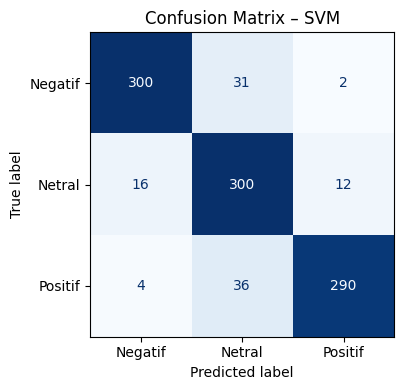

In [8]:
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42, stratify=y)

svm = LinearSVC(max_iter=5000, C=1.0)
svm.fit(X_tr3, y_tr3)
joblib.dump(svm, 'model_svm.pkl')

acc_tr3 = accuracy_score(y_tr3, svm.predict(X_tr3))
acc_te3 = accuracy_score(y_te3, svm.predict(X_te3))

print(f"=== Skema 3 – SVM + TF-IDF (80/20) ===")
print(f"Train Accuracy : {acc_tr3:.4f}")
print(f"Test  Accuracy : {acc_te3:.4f}")
print(classification_report(y_te3, svm.predict(X_te3), target_names=le.classes_))

fig,ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_te3,svm.predict(X_te3)),
    display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – SVM')
plt.tight_layout(); plt.savefig('cm_svm.png', dpi=120); plt.show()


## 7. Tokenisasi untuk Deep Learning

In [9]:
MAX_VOCAB = 25000; MAX_LEN = 100; EMBED_DIM = 128

tokenizer_dl = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(df['clean_text'])
sequences = tokenizer_dl.texts_to_sequences(df['clean_text'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_cat = to_categorical(y, num_classes=3)
joblib.dump(tokenizer_dl, 'tokenizer_dl.pkl')
print(f"X_seq: {X_seq.shape}")


X_seq: (4953, 100)


## 8. Skema 1 – Conv1D + Embedding (Split 80/20)

In [10]:
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_seq, y_cat, test_size=0.20, random_state=42, stratify=y)

model_conv = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    SpatialDropout1D(0.2),
    Conv1D(256, 5, activation='relu', padding='same'),
    Conv1D(128, 3, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'), Dropout(0.4),
    Dense(64,  activation='relu'), Dropout(0.2),
    Dense(3,   activation='softmax'),
], name='Conv1D_Model')
model_conv.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
model_conv.summary()

cbs1 = [EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss')]
history1 = model_conv.fit(X_tr1, y_tr1, epochs=30, batch_size=32,
    validation_data=(X_te1, y_te1), callbacks=cbs1, verbose=1)
model_conv.save('model_conv1d.keras')


Model: "Conv1D_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

115/124 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9921 - loss: 0.0286

118/124 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9921 - loss: 0.0285

121/124 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9921 - loss: 0.0285

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9921 - loss: 0.0284

124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9927 - loss: 0.0258 - val_accuracy: 0.9183 - val_loss: 0.3877 - learning_rate: 5.0000e-04


=== Skema 1 – Conv1D (80/20) ===
Train Accuracy : 0.9753
Test  Accuracy : 0.9294
              precision    recall  f1-score   support

     Negatif       0.98      0.96      0.97       333
      Netral       0.89      0.90      0.90       328
     Positif       0.92      0.92      0.92       330

    accuracy                           0.93       991
   macro avg       0.93      0.93      0.93       991
weighted avg       0.93      0.93      0.93       991



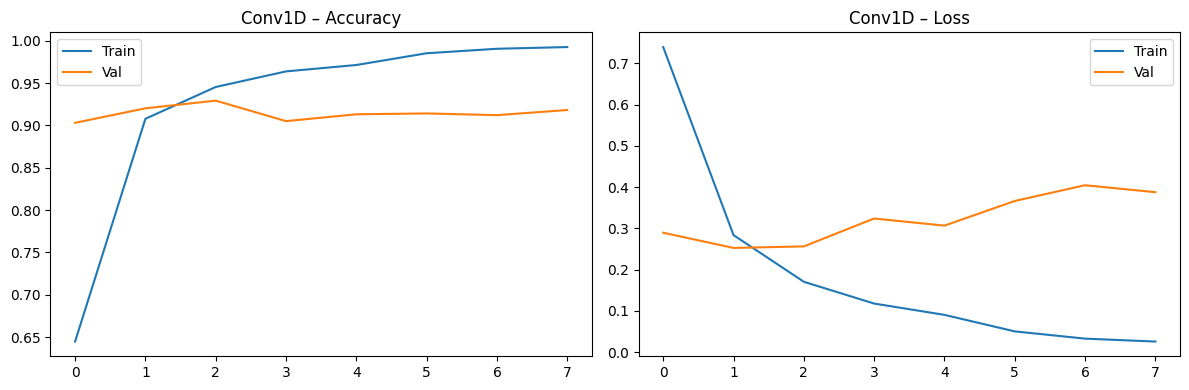

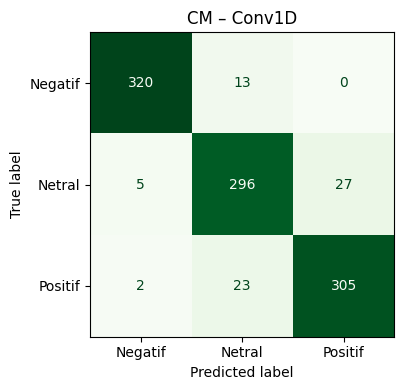

In [11]:
y_pred1    = np.argmax(model_conv.predict(X_te1, verbose=0), axis=1)
y_true1    = np.argmax(y_te1, axis=1)
y_pred1_tr = np.argmax(model_conv.predict(X_tr1, verbose=0), axis=1)
y_true1_tr = np.argmax(y_tr1, axis=1)
acc_tr1 = accuracy_score(y_true1_tr, y_pred1_tr)
acc_te1 = accuracy_score(y_true1,    y_pred1)

print("=== Skema 1 – Conv1D (80/20) ===")
print(f"Train Accuracy : {acc_tr1:.4f}")
print(f"Test  Accuracy : {acc_te1:.4f}")
print(classification_report(y_true1, y_pred1, target_names=le.classes_))

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history1.history['accuracy'],    label='Train')
axes[0].plot(history1.history['val_accuracy'],label='Val')
axes[0].set_title('Conv1D – Accuracy'); axes[0].legend()
axes[1].plot(history1.history['loss'],    label='Train')
axes[1].plot(history1.history['val_loss'],label='Val')
axes[1].set_title('Conv1D – Loss'); axes[1].legend()
plt.tight_layout(); plt.savefig('history_conv1d.png', dpi=120); plt.show()

fig,ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_true1,y_pred1),
    display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('CM – Conv1D'); plt.tight_layout()
plt.savefig('cm_conv1d.png', dpi=120); plt.show()


## 9. Skema 2 – Bi-LSTM + Word2Vec (Split 80/20)

In [12]:
# Latih Word2Vec pada data
corpus = [t.split() for t in df['clean_text']]
w2v = Word2Vec(corpus, vector_size=EMBED_DIM, window=5,
               min_count=1, workers=4, epochs=15, seed=42)
w2v.save('word2vec.model')
print("Word2Vec vocab:", len(w2v.wv))

vocab_sz   = min(MAX_VOCAB, len(tokenizer_dl.word_index)+1)
embed_mx   = np.zeros((vocab_sz, EMBED_DIM))
for word,idx in tokenizer_dl.word_index.items():
    if idx < vocab_sz and word in w2v.wv:
        embed_mx[idx] = w2v.wv[word]
print("Embed matrix:", embed_mx.shape)


Word2Vec vocab: 5359
Embed matrix: (5361, 128)


In [13]:
model_bilstm = Sequential([
    Embedding(vocab_sz, EMBED_DIM, weights=[embed_mx],
              input_length=MAX_LEN, trainable=True),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(128, dropout=0.3, return_sequences=True)),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(64, activation='relu'), Dropout(0.3),
    Dense(3,  activation='softmax'),
], name='BiLSTM_Model')
model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
model_bilstm.summary()

cbs2 = [EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss')]
history2 = model_bilstm.fit(X_tr1, y_tr1, epochs=30, batch_size=64,
    validation_data=(X_te1, y_te1), callbacks=cbs2, verbose=1)
model_bilstm.save('model_bilstm.keras')


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │       686,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,208 (2.62 MB)

 Trainable params: 686,208 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

...

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9787 - loss: 0.0605

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9788 - loss: 0.0605

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9788 - loss: 0.0605

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9788 - loss: 0.0605

62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.9811 - loss: 0.0605 - val_accuracy: 0.9021 - val_loss: 0.3773 - learning_rate: 5.0000e-04


=== Skema 2 – Bi-LSTM + Word2Vec (80/20) ===
Train Accuracy : 0.9758
Test  Accuracy : 0.9082
              precision    recall  f1-score   support

     Negatif       0.93      0.96      0.94       333
      Netral       0.83      0.92      0.88       328
     Positif       0.98      0.84      0.91       330

    accuracy                           0.91       991
   macro avg       0.91      0.91      0.91       991
weighted avg       0.91      0.91      0.91       991



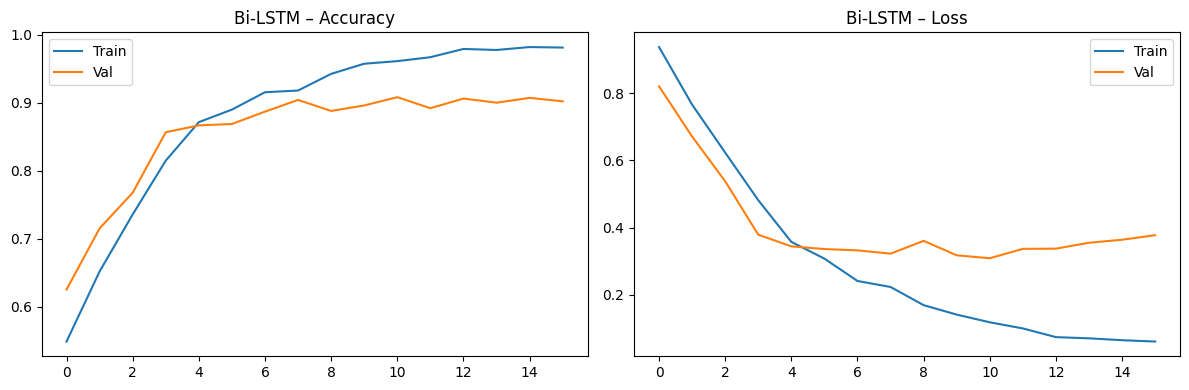

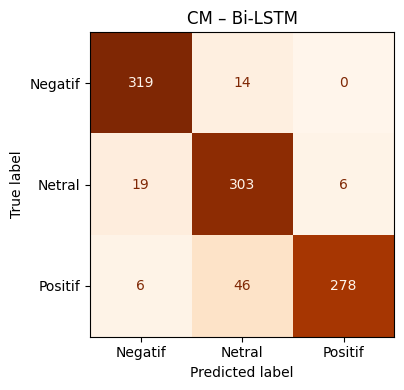

In [14]:
y_pred2    = np.argmax(model_bilstm.predict(X_te1, verbose=0), axis=1)
y_true2    = np.argmax(y_te1, axis=1)
y_pred2_tr = np.argmax(model_bilstm.predict(X_tr1, verbose=0), axis=1)
y_true2_tr = np.argmax(y_tr1, axis=1)
acc_tr2 = accuracy_score(y_true2_tr, y_pred2_tr)
acc_te2 = accuracy_score(y_true2,    y_pred2)

print("=== Skema 2 – Bi-LSTM + Word2Vec (80/20) ===")
print(f"Train Accuracy : {acc_tr2:.4f}")
print(f"Test  Accuracy : {acc_te2:.4f}")
print(classification_report(y_true2, y_pred2, target_names=le.classes_))

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history2.history['accuracy'],    label='Train')
axes[0].plot(history2.history['val_accuracy'],label='Val')
axes[0].set_title('Bi-LSTM – Accuracy'); axes[0].legend()
axes[1].plot(history2.history['loss'],    label='Train')
axes[1].plot(history2.history['val_loss'],label='Val')
axes[1].set_title('Bi-LSTM – Loss'); axes[1].legend()
plt.tight_layout(); plt.savefig('history_bilstm.png', dpi=120); plt.show()

fig,ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_true2,y_pred2),
    display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('CM – Bi-LSTM'); plt.tight_layout()
plt.savefig('cm_bilstm.png', dpi=120); plt.show()


## 10. Ringkasan Hasil

                        Skema Algoritma     Fitur Split Train Acc Test Acc
     Skema 1 – Conv1D (80/20)    Conv1D Embedding 80/20    0.9753   0.9294
Skema 2 – Bi-LSTM+W2V (80/20)   Bi-LSTM  Word2Vec 80/20    0.9758   0.9082
 Skema 3 – SVM+TF-IDF (80/20) LinearSVC    TF-IDF 80/20    0.9955   0.8981


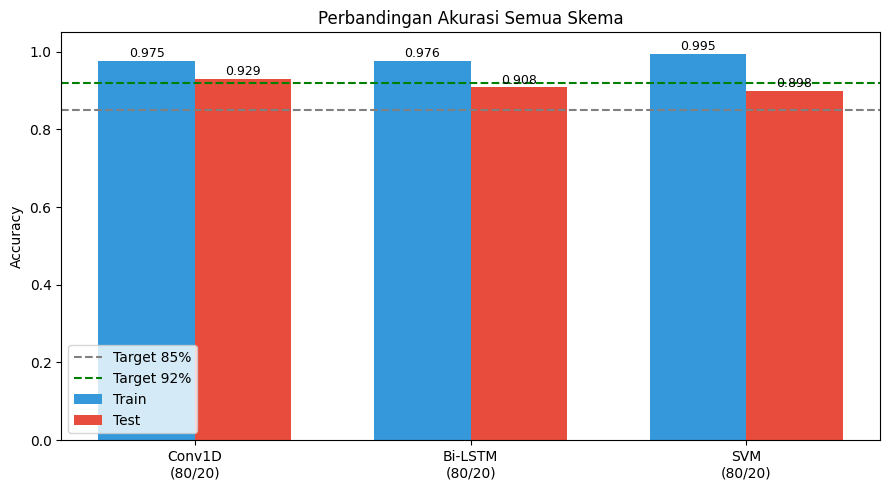

In [15]:
summary = pd.DataFrame({
    'Skema'     : ['Skema 1 – Conv1D (80/20)',
                   'Skema 2 – Bi-LSTM+W2V (80/20)',
                   'Skema 3 – SVM+TF-IDF (80/20)'],
    'Algoritma' : ['Conv1D','Bi-LSTM','LinearSVC'],
    'Fitur'     : ['Embedding','Word2Vec','TF-IDF'],
    'Split'     : ['80/20','80/20','80/20'],
    'Train Acc' : [f"{acc_tr1:.4f}",f"{acc_tr2:.4f}",f"{acc_tr3:.4f}"],
    'Test Acc'  : [f"{acc_te1:.4f}",f"{acc_te2:.4f}",f"{acc_te3:.4f}"],
})
print(summary.to_string(index=False))

x=np.arange(3); w=0.35
fig,ax=plt.subplots(figsize=(9,5))
b1=ax.bar(x-w/2,[acc_tr1,acc_tr2,acc_tr3],w,label='Train',color='#3498db')
b2=ax.bar(x+w/2,[acc_te1,acc_te2,acc_te3],w,label='Test', color='#e74c3c')
ax.axhline(0.85,color='gray', linestyle='--',label='Target 85%')
ax.axhline(0.92,color='green',linestyle='--',label='Target 92%')
ax.set_xticks(x)
ax.set_xticklabels(['Conv1D\n(80/20)','Bi-LSTM\n(80/20)','SVM\n(80/20)'])
ax.set_ylim(0,1.05); ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi Semua Skema'); ax.legend()
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('perbandingan_akurasi.png', dpi=120); plt.show()


## 11. Inference – Prediksi Sentimen Teks Baru

In [16]:
def predict_sentiment(text, model_name='conv1d'):
    """
    Prediksi sentimen dari teks ulasan.
    
    Args:
        text       : str – teks ulasan yang ingin diprediksi
        model_name : str – 'conv1d' | 'bilstm' | 'svm'
    
    Returns:
        str – label sentimen: 'Positif', 'Netral', atau 'Negatif'
    """
    clean = preprocess(text)
    if model_name == 'svm':
        pred = int(svm.predict(tfidf.transform([clean]))[0])
    else:
        pad = pad_sequences(tokenizer_dl.texts_to_sequences([clean]),
                            maxlen=MAX_LEN, padding='post')
        m   = model_conv if model_name == 'conv1d' else model_bilstm
        pred = int(np.argmax(m.predict(pad, verbose=0)[0]))
    return le.inverse_transform([pred])[0]

# ── Contoh inferensi ──────────────────────────────────────────────────────
test_cases = [
    ("Aplikasi ini sangat bagus dan mudah digunakan, saya sangat puas!",    "Positif"),
    ("Biasa saja aplikasinya",                                              "Netral"),
    ("Aplikasi sering crash dan sangat lambat, sangat mengecewakan!",       "Negatif"),
    ("Pengiriman cepat, barang sesuai deskripsi, sangat recommended!",      "Positif"),
    ("Untuk sehari-hari ini cukup",                                         "Netral"),
    ("Update terbaru memperburuk performa, banyak bug bermunculan",         "Negatif"),
    ("Fitur baru sangat membantu, UI lebih fresh dan responsif",            "Positif"),
    ("Mohon dilihat kembali, tapi masih bisa dipakai",                      "Netral"),
]

print("=" * 76)
print(f"{'Teks Ulasan':<44}|{'Label':^9}|{'Conv1D':^8}|{'BiLSTM':^8}|{'SVM':^6}")
print("=" * 76)
for teks, lbl in test_cases:
    s  = teks[:41]+"..." if len(teks) > 41 else teks
    p1 = predict_sentiment(teks, 'conv1d')
    p2 = predict_sentiment(teks, 'bilstm')
    p3 = predict_sentiment(teks, 'svm')
    print(f"{s:<44}|{lbl:^9}|{p1:^8}|{p2:^8}|{p3:^6}")
print("=" * 76)


Teks Ulasan                                 |  Label  | Conv1D | BiLSTM | SVM  
Aplikasi ini sangat bagus dan mudah digun...| Positif |Positif |Positif |Positif
Biasa saja aplikasinya                      | Netral  | Netral | Netral |Positif


Aplikasi sering crash dan sangat lambat, ...| Negatif |Negatif |Negatif |Negatif


Pengiriman cepat, barang sesuai deskripsi...| Positif |Positif |Positif |Positif
Untuk sehari-hari ini cukup                 | Netral  | Netral | Netral |Netral
Update terbaru memperburuk performa, bany...| Negatif |Negatif |Negatif |Negatif


Fitur baru sangat membantu, UI lebih fres...| Positif | Netral | Netral |Netral


Mohon dilihat kembali, tapi masih bisa di...| Netral  |Positif | Netral |Netral


In [17]:
# Inferensi kustom – ubah teks sesuai kebutuhan
teks_uji = "Aplikasinya sangat membantu sehari-hari, fitur lengkap dan cepat digunakan"
print(f"Input   : {teks_uji}")
print(f"Conv1D  : {predict_sentiment(teks_uji, 'conv1d')}")
print(f"Bi-LSTM : {predict_sentiment(teks_uji, 'bilstm')}")
print(f"SVM     : {predict_sentiment(teks_uji, 'svm')}")


Input   : Aplikasinya sangat membantu sehari-hari, fitur lengkap dan cepat digunakan
Conv1D  : Positif
Bi-LSTM : Positif
SVM     : Positif
